In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df=pd.read_csv(r'C:\Users\sdsha\OneDrive\Desktop\m\2026\ML\Apartment-Price-Predictor\data\raw\Indian_House_Price.csv')
df.shape

(9390, 44)

In [3]:
df.columns

Index(['Unnamed: 0', 'Price', 'Area', 'Location', 'No. of Bedrooms', 'Resale',
       'MaintenanceStaff', 'Gymnasium', 'SwimmingPool', 'LandscapedGardens',
       'JoggingTrack', 'RainWaterHarvesting', 'IndoorGames', 'ShoppingMall',
       'Intercom', 'SportsFacility', 'ATM', 'ClubHouse', 'School',
       '24X7Security', 'PowerBackup', 'CarParking', 'StaffQuarter',
       'Cafeteria', 'MultipurposeRoom', 'Hospital', 'WashingMachine',
       'Gasconnection', 'AC', 'Wifi', 'Children'splayarea', 'LiftAvailable',
       'BED', 'VaastuCompliant', 'Microwave', 'GolfCourse', 'TV',
       'DiningTable', 'Sofa', 'Wardrobe', 'Refrigerator', 'City', 'Latitude',
       'Longitude'],
      dtype='str')

In [4]:
df['City'].value_counts()

City
Hyderabad    2276
Chennai      2047
Delhi        1989
Banglore     1708
Mumbai       1302
Kolkata        68
Name: count, dtype: int64

In [5]:
df=df[df['City']=="Hyderabad"]

In [6]:
df=df.reset_index(drop=True)

In [7]:
df.shape

(2276, 44)

In [8]:
df.isnull().sum()

Unnamed: 0             0
Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0


In [9]:
df.columns=(
    df.columns
            .str.strip()
            .str.lower()
            .str.replace(" ","_")
            .str.replace(".","",regex=False)
            )

In [10]:
df.columns

Index(['unnamed:_0', 'price', 'area', 'location', 'no_of_bedrooms', 'resale',
       'maintenancestaff', 'gymnasium', 'swimmingpool', 'landscapedgardens',
       'joggingtrack', 'rainwaterharvesting', 'indoorgames', 'shoppingmall',
       'intercom', 'sportsfacility', 'atm', 'clubhouse', 'school',
       '24x7security', 'powerbackup', 'carparking', 'staffquarter',
       'cafeteria', 'multipurposeroom', 'hospital', 'washingmachine',
       'gasconnection', 'ac', 'wifi', 'children'splayarea', 'liftavailable',
       'bed', 'vaastucompliant', 'microwave', 'golfcourse', 'tv',
       'diningtable', 'sofa', 'wardrobe', 'refrigerator', 'city', 'latitude',
       'longitude'],
      dtype='str')

In [11]:
feature_summary=pd.DataFrame({
    "columns":df.columns,
    "dtype":df.dtypes,
    "missing":df.isnull().sum(),
    "uniqe_values":df.nunique()
})
feature_summary

,columns,dtype,missing,uniqe_values
unnamed:_0,unnamed:_0,int64,0,2276
price,price,float64,0,632
area,area,int64,0,547
location,location,str,0,207
no_of_bedrooms,no_of_bedrooms,float64,0,7
resale,resale,int64,0,2
maintenancestaff,maintenancestaff,float64,0,2
gymnasium,gymnasium,float64,0,2
swimmingpool,swimmingpool,float64,0,2
landscapedgardens,landscapedgardens,float64,0,2


In [12]:
df=df.drop(columns=['unnamed:_0'])
df.head()


,price,area,location,no_of_bedrooms,resale,maintenancestaff,gymnasium,swimmingpool,landscapedgardens,joggingtrack,...,microwave,golfcourse,tv,diningtable,sofa,wardrobe,refrigerator,city,latitude,longitude
0,69.68,1340,Nizampet,2.0,0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.515397,78.381716
1,290.00,3498,Hitech City,4.0,0,0.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.451523,78.382578
2,65.90,1318,Manikonda,2.0,0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,16.449897,80.833460
3,57.39,1295,Alwal,3.0,1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.502229,78.508858
4,56.79,1145,Kukatpally,2.0,0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.493084,78.405441


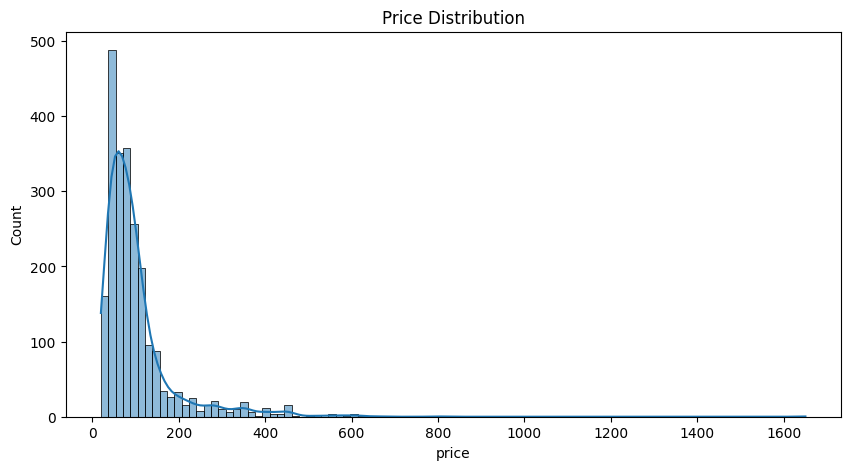

In [13]:
target='price'
plt.figure(figsize=(10,5))
sns.histplot(df[target],kde=True)
plt.title("Price Distribution")
plt.show()

In [14]:
df["price"].skew()

np.float64(4.579679366135271)

<Axes: xlabel='log_price', ylabel='Count'>

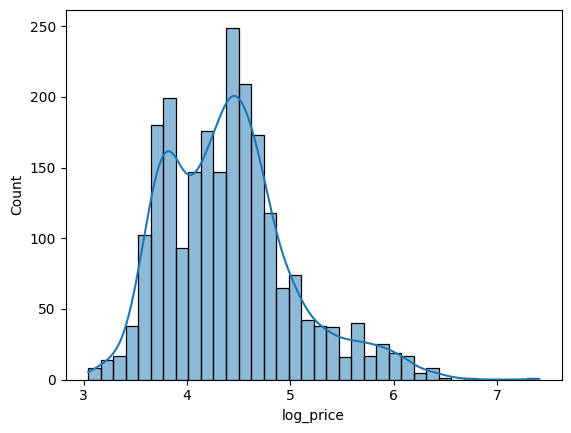

In [15]:
df['log_price']=np.log1p(df['price'])
sns.histplot(df['log_price'],kde=True)

<Axes: xlabel='area', ylabel='price'>

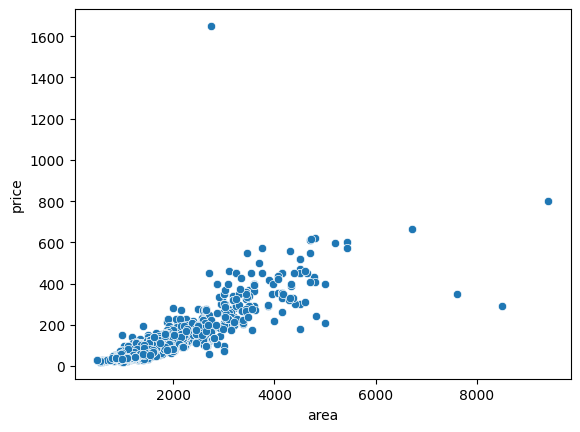

In [16]:
sns.scatterplot(
    x=df['area'],
    y=df['price']
)

<Axes: xlabel='no_of_bedrooms', ylabel='price'>

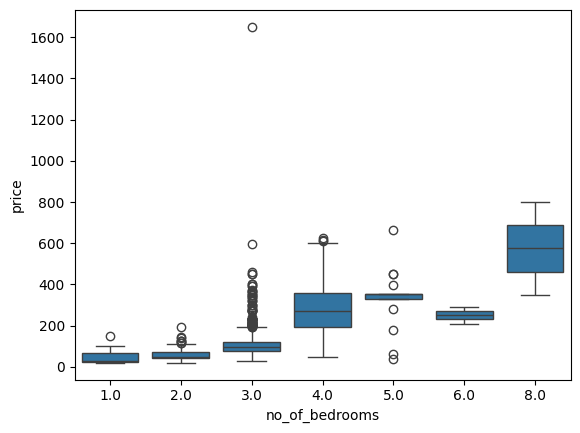

In [17]:
sns.boxplot(
    x=df['no_of_bedrooms'],
    y=df['price']
)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Kukatpally'),
  Text(1, 0, 'Kondapur'),
  Text(2, 0, 'Manikonda'),
  Text(3, 0, 'Nizampet'),
  Text(4, 0, 'Hitech City'),
  Text(5, 0, 'Gachibowli'),
  Text(6, 0, 'Kokapet'),
  Text(7, 0, 'Miyapur'),
  Text(8, 0, 'Pragathi Nagar Kukatpally'),
  Text(9, 0, 'Bachupally Road')])

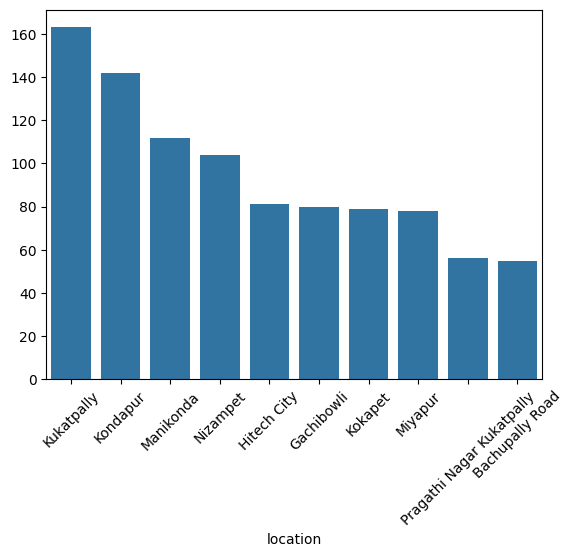

In [18]:
top_locations=(
    df['location'].value_counts().head(10)
)
sns.barplot(
    x=top_locations.index,
    y=top_locations.values
)
plt.xticks(rotation=45)

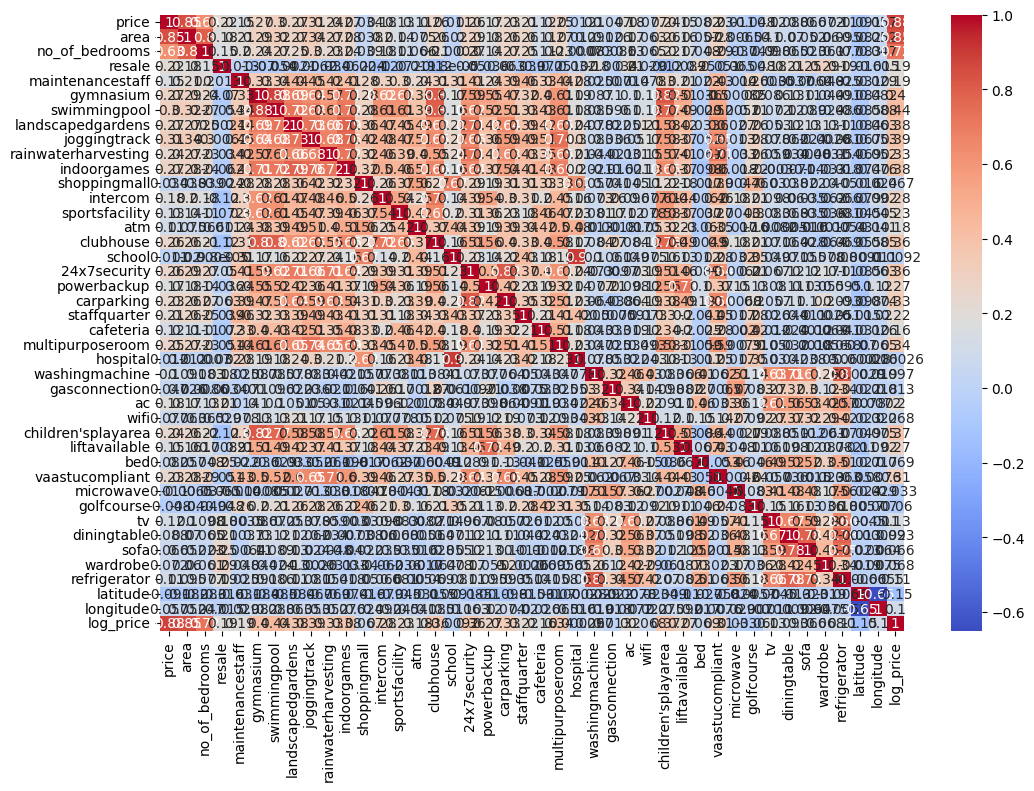

In [19]:
numeric_df=df.select_dtypes(include=np.number)
corr=numeric_df.corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [20]:
corr["price"].sort_values(ascending=False)

price                  1.000000
log_price              0.877963
area                   0.846596
no_of_bedrooms         0.631244
joggingtrack           0.311356
swimmingpool           0.304044
gymnasium              0.274079
indoorgames            0.271452
landscapedgardens      0.269532
clubhouse              0.256993
24x7security           0.256193
multipurposeroom       0.253616
children'splayarea     0.244356
rainwaterharvesting    0.240993
carparking             0.234783
vaastucompliant        0.227744
resale                 0.215673
staffquarter           0.210865
ac                     0.182821
intercom               0.179700
powerbackup            0.171748
maintenancestaff       0.150657
liftavailable          0.147582
sportsfacility         0.131089
tv                     0.124785
cafeteria              0.120503
refrigerator           0.106694
atm                    0.105890
washingmachine         0.104903
diningtable            0.087754
bed                    0.081846
wifi    

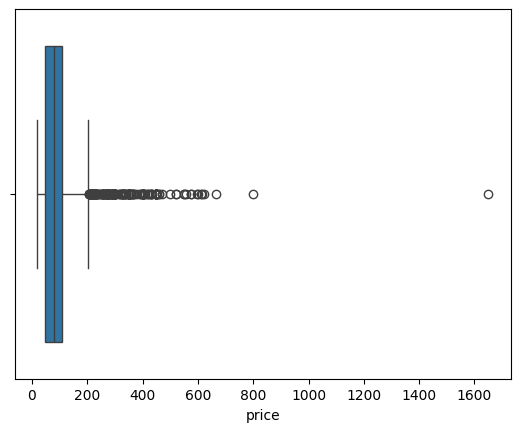

In [21]:
plt.Figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.show()

In [22]:
y=df['log_price']

baseline=y.mean()

baseline_preds=np.full(
    len(y),
    baseline
)

rmse=np.sqrt(
    mean_squared_error(
        y,
        baseline_preds
        )
    )

print(f"Baseline RMSE:{rmse}")

Baseline RMSE:0.613949428532114


In [23]:
target='log_price'
X=df.drop(columns=['price','log_price'],errors='ignore')
y=df[target]


In [24]:
X.head()

,area,location,no_of_bedrooms,resale,maintenancestaff,gymnasium,swimmingpool,landscapedgardens,joggingtrack,rainwaterharvesting,...,microwave,golfcourse,tv,diningtable,sofa,wardrobe,refrigerator,city,latitude,longitude
0,1340,Nizampet,2.0,0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.515397,78.381716
1,3498,Hitech City,4.0,0,0.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.451523,78.382578
2,1318,Manikonda,2.0,0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,16.449897,80.833460
3,1295,Alwal,3.0,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.502229,78.508858
4,1145,Kukatpally,2.0,0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Hyderabad,17.493084,78.405441


In [25]:
X.shape

(2276, 42)

In [26]:
numeric_features=X.select_dtypes(include=np.number).columns.tolist()

In [27]:
categorical_features=X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [28]:
print(f'''Numerical features:{numeric_features}
Categorical Features:{categorical_features}''')

Numerical features:['area', 'no_of_bedrooms', 'resale', 'maintenancestaff', 'gymnasium', 'swimmingpool', 'landscapedgardens', 'joggingtrack', 'rainwaterharvesting', 'indoorgames', 'shoppingmall', 'intercom', 'sportsfacility', 'atm', 'clubhouse', 'school', '24x7security', 'powerbackup', 'carparking', 'staffquarter', 'cafeteria', 'multipurposeroom', 'hospital', 'washingmachine', 'gasconnection', 'ac', 'wifi', "children'splayarea", 'liftavailable', 'bed', 'vaastucompliant', 'microwave', 'golfcourse', 'tv', 'diningtable', 'sofa', 'wardrobe', 'refrigerator', 'latitude', 'longitude']
Categorical Features:['location', 'city']


In [29]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
numeric_transformer=Pipeline([
    (
        "imputer",
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

In [31]:
categorical_transformer=Pipeline([
    (
        "imputer",
        SimpleImputer(strategy='most_frequent')
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown='ignore'
        )
    )
])

In [32]:
preprocessor=ColumnTransformer([
    (
        'num',
        numeric_transformer,
        numeric_features

    ),
    (
        'cat',
        categorical_transformer,
        categorical_features
    )
])

In [33]:
lr_pipline=Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        LinearRegression()
    )
])

In [34]:
ridge_pipline=Pipeline([
    (
        'preprocessor',
        preprocessor
    ),
    (
        'model',
        Ridge(alpha=1.0)
    )
])

In [35]:
lasso_pipline=Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        'model',
        Lasso(alpha=0.01)
    )
])

In [36]:
lr_pipline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [37]:
ridge_pipline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [38]:
lasso_pipline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [39]:
def evaluate_model(model,X_test,y_test):
    preds=model.predict(X_test)
    rmse=np.sqrt(
        mean_absolute_error(
            y_test,
            preds
        )
    )
    mae=mean_absolute_error(
        y_test,
        preds
    )
    r2=r2_score(
        y_test,
        preds
    )
    print(f'''RMSE:{rmse}
MAE:{mae}
R^2:{r2}''')
    return preds

In [40]:
lr_pred=evaluate_model(
    lr_pipline,
    X_test,
    y_test
)

RMSE:0.39332049254393814
MAE:0.1547010098550061
R^2:0.889289190283064


In [41]:
ridge_preds=evaluate_model(
    ridge_pipline,
    X_test,
    y_test
)

RMSE:0.3911349058454958
MAE:0.15298651457076487
R^2:0.8942592737225816


In [42]:
lasso_preds=evaluate_model(
    lasso_pipline,
    X_test,
    y_test
)

RMSE:0.46377706268136953
MAE:0.21508916386935895
R^2:0.8222561441951711


In [43]:
results=pd.DataFrame({
    'Model':[
        "Baseline",
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],
    "RMSE":[
        rmse,
        np.sqrt(mean_squared_error(y_test,lr_pred)),
        np.sqrt(mean_squared_error(y_test,ridge_preds)),
        np.sqrt(mean_squared_error(y_test,lasso_preds))
    ]
}
)
results

,Model,RMSE
0,Baseline,0.613949
1,Linear Regression,0.221899
2,Ridge,0.216861
3,Lasso,0.281162


In [44]:
residuals=y_test-lr_pred

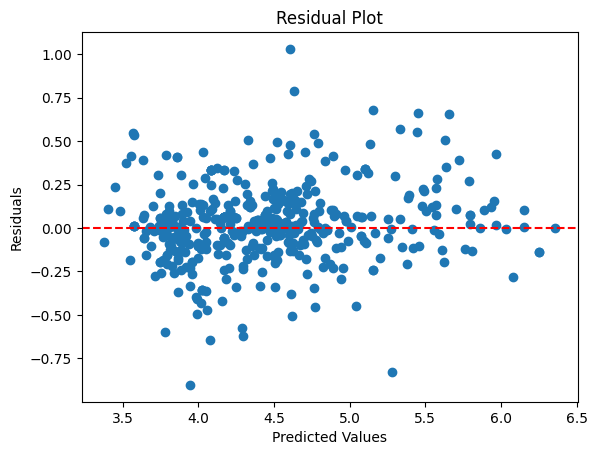

In [45]:
plt.Figure(figsize=(8,5))
plt.scatter(
    lr_pred,
    residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

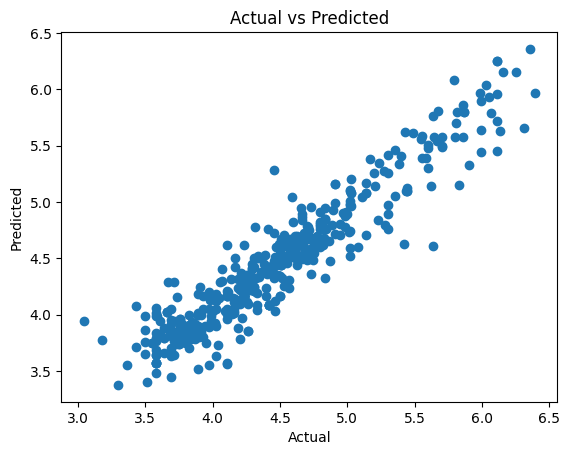

In [46]:
plt.Figure(figsize=(8,5))
plt.scatter(
    y_test,
    lr_pred
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [47]:
model=lr_pipline.named_steps['model']
model.coef_

array([ 3.19531693e-01,  5.81766881e-02,  1.17446510e-02, -1.86248632e-02,
       -2.69867499e-03,  3.08121120e-02,  2.32689833e-02, -6.71187837e-03,
       -1.17835147e-02,  7.90950017e-03,  2.99516028e-02, -3.27159492e-03,
        2.26813277e-02,  1.98735595e-02, -1.42506873e-02, -6.44414079e-02,
       -6.06156954e-03,  2.02061972e-02, -1.47617048e-02, -2.09474956e-02,
       -1.85288161e-02,  3.49890601e-02,  3.44165372e-02, -9.53083900e-03,
       -1.09389950e-02,  2.13296706e-02, -6.02601255e-03,  1.92258009e-02,
        1.33080196e-02,  2.13285882e-02,  1.68667927e-02, -1.82354152e-02,
       -4.67597535e-02,  2.59253819e-02, -1.65072495e-02, -1.51730258e-02,
       -2.41303707e-02,  2.98161226e-02, -1.97061339e-02,  1.24124978e-02,
       -2.58519126e-01,  5.09022515e-02, -7.45591796e-03, -2.16407536e-02,
       -8.56887087e-02, -1.07882040e-01, -2.06373354e-01,  4.14136965e-02,
       -1.67957756e-01, -2.27705575e-02, -8.56245296e-02,  1.88126481e-01,
        4.05998414e-01, -

In [48]:
feature_names=(
    numeric_features 
    +
    list(
        lr_pipline.named_steps[
            "preprocessor"
        ]
        .named_transformers_[
            'cat'
        ]
        .named_steps[
            'encoder'
        ].get_feature_names_out(
            categorical_features
        )
    )
)

In [49]:
coef_df=pd.DataFrame({
    'feature':feature_names,
    'coefficent':model.coef_
})
coef_df.sort_values(
    by='coefficent',
    ascending=False
).head(15)

,feature,coefficent
189,location_Saket,1.220415
66,location_Banjara Hills Road Number 12,0.851469
65,location_Banjara Hills,0.649600
79,location_Chikkadapally,0.646618
214,location_Vidyanagar Adikmet,0.580731
109,location_Jubilee Hills,0.579967
68,location_Basheer Bagh,0.549228
84,location_Domalguda Road,0.547357
159,location_Nandagiri Hills,0.523316
83,location_Domalguda,0.506621
